# Phase 5 : Random Forest + XGBoost + Imbalance Handling + Model Comparison

In [7]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

In [8]:
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [9]:
print(df.columns.tolist())

['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'churn_flag']


In [10]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [11]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

In [12]:
df["total_services"] = 0

df["total_services"] += (df["phoneservice"] == "Yes").astype(int)

df["total_services"] += (df["multiplelines"] == "Yes").astype(int)

df["total_services"] += (df["internetservice"] != "No").astype(int)

In [13]:
service_columns = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

for col in service_columns:
    df["total_services"] += (df[col] == "Yes").astype(int)

In [14]:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["totalcharges"] / df["tenure"],
    0
)

df["automatic_payment"] = df["paymentmethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)

df["is_month_to_month"] = (
    df["contract"] == "Month-to-month"
).astype(int)

df["has_tech_support"] = (
    df["techsupport"] == "Yes"
).astype(int)

In [15]:
X = df.drop(
    columns=[
        "customerid",
        "churn",
        "churn_flag"
    ]
)

y = df["churn_flag"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
# Understand class imbalance again
y_train.value_counts()

churn_flag
0    4139
1    1495
Name: count, dtype: int64

In [18]:
y_train.value_counts(normalize=True)

churn_flag
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [20]:
# calculate counts:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

print("Non-Churn:", negative_count)
print("Churn:", positive_count)

Non-Churn: 4139
Churn: 1495


In [21]:
# Calculate ratio:
imbalance_ratio = negative_count / positive_count

print("Imbalance ratio:", imbalance_ratio)

Imbalance ratio: 2.768561872909699


In [24]:
# Imports
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression


# 1. Find numeric columns
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()


# 2. Find categorical columns
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# 3. Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)


# 4. Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


# 5. Combine both
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_31324\3373448104.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [25]:
# MODEL 1 — Normal Logistic Regression
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [26]:
clone(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [27]:
# MODEL 2 — Weighted Logistic Regression
balanced_logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [28]:
class_weight="balanced"

In [29]:
# MODEL 3 — Random Forest
from sklearn.ensemble import RandomForestClassifier

In [30]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [31]:
# MODEL 4 — XGBoost
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,

                subsample=0.8,
                colsample_bytree=0.8,

                objective="binary:logistic",

                eval_metric="logloss",

                scale_pos_weight=imbalance_ratio,

                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [32]:
n_estimators=300

In [33]:
learning_rate=0.05

In [34]:
max_depth=4

In [35]:
subsample=0.8

In [36]:
colsample_bytree=0.8

In [37]:
scale_pos_weight=imbalance_ratio

In [38]:
# Create a model dictionary
models = {
    "Logistic Regression": logistic_model,
    "Balanced Logistic Regression": balanced_logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

In [39]:
models.keys()

dict_keys(['Logistic Regression', 'Balanced Logistic Regression', 'Random Forest', 'XGBoost'])

In [40]:
# Build 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
# Define evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [42]:
# Cross-validate all models
cv_results = []

In [44]:
for name, model in models.items():

    print(f"Training: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append(
        {
            "Model": name,

            "Accuracy": scores[
                "test_accuracy"
            ].mean(),

            "Precision": scores[
                "test_precision"
            ].mean(),

            "Recall": scores[
                "test_recall"
            ].mean(),

            "F1": scores[
                "test_f1"
            ].mean(),

            "ROC_AUC": scores[
                "test_roc_auc"
            ].mean(),

            "PR_AUC": scores[
                "test_pr_auc"
            ].mean()
        }
    )

Training: Logistic Regression
Training: Balanced Logistic Regression
Training: Random Forest
Training: XGBoost


In [45]:
# Create comparison table
comparison_df = pd.DataFrame(
    cv_results
)

In [46]:
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.807777,0.673841,0.534448,0.595623,0.847276,0.662971
1,Balanced Logistic Regression,0.750270,0.519337,0.793311,0.627581,0.847236,0.661183
2,Random Forest,0.775294,0.566382,0.652174,0.606222,0.827692,0.616455
3,XGBoost,0.764645,0.539232,0.776589,0.636425,0.844092,0.659947
4,Logistic Regression,0.807777,0.673841,0.534448,0.595623,0.847276,0.662971
5,Balanced Logistic Regression,0.750270,0.519337,0.793311,0.627581,0.847236,0.661183
6,Random Forest,0.775294,0.566382,0.652174,0.606222,0.827692,0.616455
7,XGBoost,0.764645,0.539232,0.776589,0.636425,0.844092,0.659947


In [48]:
# Formtaing
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599


In [49]:
# Sort by ROC-AUC
comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165


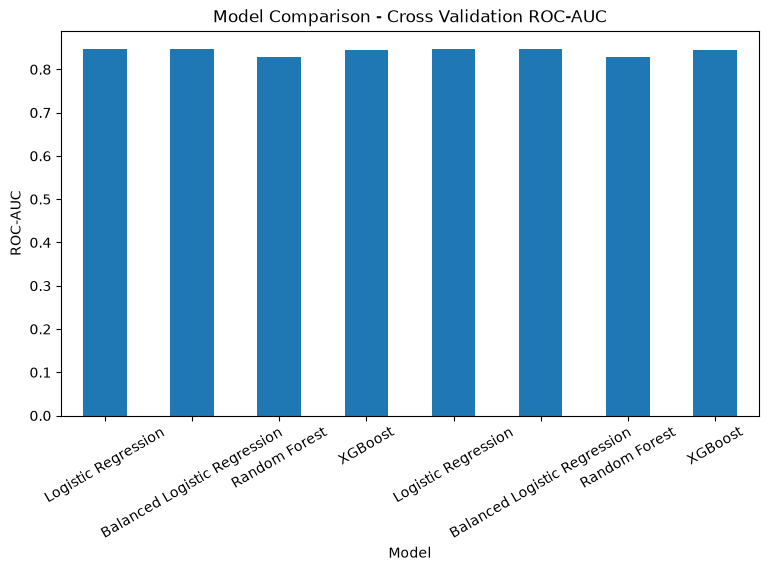

In [50]:
# Visualize model comparison
comparison_df.set_index(
    "Model"
)["ROC_AUC"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Comparison - Cross Validation ROC-AUC"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")

plt.xticks(rotation=30)

plt.show()

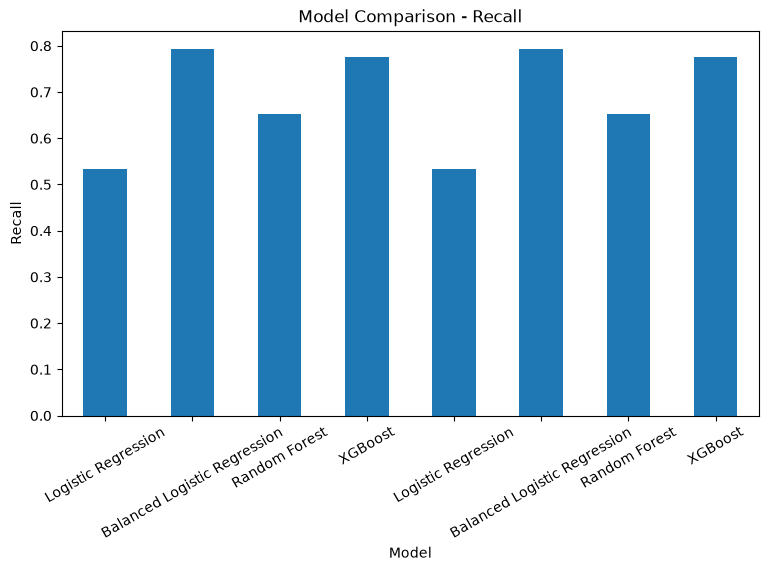

In [51]:
# Recall
comparison_df.set_index(
    "Model"
)["Recall"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Comparison - Recall"
)

plt.ylabel("Recall")

plt.xticks(rotation=30)

plt.show()

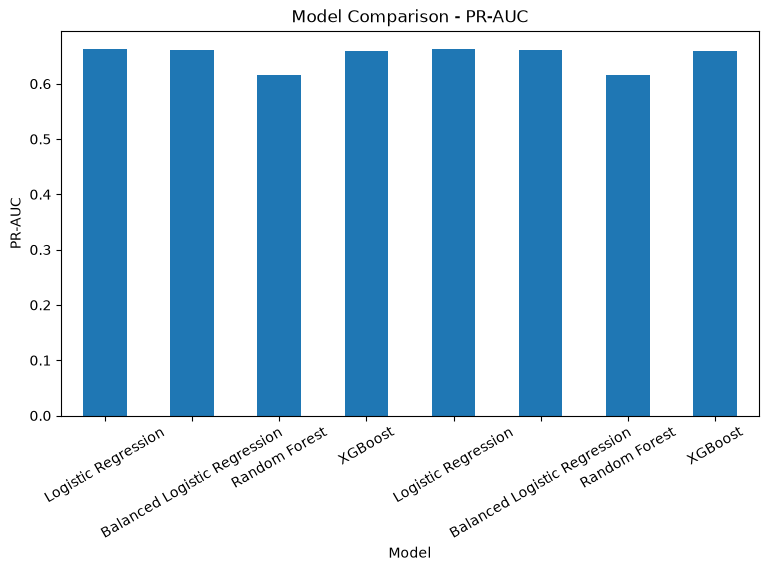

In [52]:
# PR-AUC:
comparison_df.set_index(
    "Model"
)["PR_AUC"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Model Comparison - PR-AUC"
)

plt.ylabel("PR-AUC")

plt.xticks(rotation=30)

plt.show()

In [53]:
# Compare overfitting for Random Forest
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [55]:
# Training score:
rf_train_pred = random_forest_model.predict(
    X_train
)

print(
    "Training Accuracy:",
    accuracy_score(
        y_train,
        rf_train_pred
    )
)

Training Accuracy: 0.9950301739439119


In [56]:
# XGBoost
xgb_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [57]:
# Training
xgb_train_pred = xgb_model.predict(
    X_train
)

print(
    "XGBoost Training Accuracy:",
    accuracy_score(
        y_train,
        xgb_train_pred
    )
)

XGBoost Training Accuracy: 0.8171813986510472


In [58]:
# Create a better business metric table
business_comparison = comparison_df[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
]

In [59]:
business_comparison.sort_values(
    by="Recall",
    ascending=False
).round(4)

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Balanced Logistic Regression,0.5193,0.7933,0.6276,0.8472,0.6612
5,Balanced Logistic Regression,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.5392,0.7766,0.6364,0.8441,0.6599
6,Random Forest,0.5664,0.6522,0.6062,0.8277,0.6165
2,Random Forest,0.5664,0.6522,0.6062,0.8277,0.6165
0,Logistic Regression,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.6738,0.5344,0.5956,0.8473,0.6630


In [61]:
# Final Test Evaluation
# Set 
final_model = xgb_model

In [62]:
# Fit
final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [63]:
# Predict
y_pred = final_model.predict(
    X_test
)

In [64]:
# Probability
y_prob = final_model.predict_proba(
    X_test
)[:, 1]

In [65]:
# Final metrics
final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred
)

final_recall = recall_score(
    y_test,
    y_pred
)

final_f1 = f1_score(
    y_test,
    y_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob
)

final_pr_auc = average_precision_score(
    y_test,
    y_prob
)

In [66]:
# Print
print(
    "FINAL TEST RESULTS"
)

print(
    "Accuracy :",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall   :",
    round(final_recall, 4)
)

print(
    "F1       :",
    round(final_f1, 4)
)

print(
    "ROC-AUC  :",
    round(final_roc_auc, 4)
)

print(
    "PR-AUC   :",
    round(final_pr_auc, 4)
)

FINAL TEST RESULTS
Accuracy : 0.7601
Precision: 0.5331
Recall   : 0.7754
F1       : 0.6318
ROC-AUC  : 0.8414
PR-AUC   : 0.6529


In [67]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stay",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [68]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[781, 254],
       [ 84, 290]])

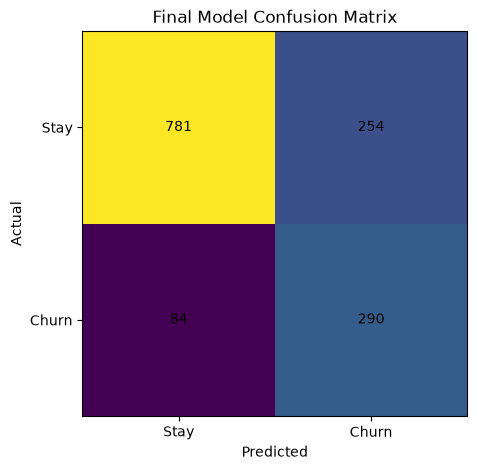

In [69]:
# Visualization :
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Stay",
    "Churn"
])

ax.set_yticklabels([
    "Stay",
    "Churn"
])

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Final Model Confusion Matrix"
)

plt.show()

In [70]:
# Examine the false negatives
error_analysis = X_test.copy()

In [71]:
error_analysis[
    "actual"
] = y_test.values

error_analysis[
    "prediction"
] = y_pred

error_analysis[
    "churn_probability"
] = y_prob

In [72]:
# false negatives:
false_negatives = error_analysis[
    (error_analysis["actual"] == 1)
    &
    (error_analysis["prediction"] == 0)
]

In [73]:
false_negatives[
    [
        "tenure",
        "contract",
        "monthlycharges",
        "internetservice",
        "techsupport",
        "churn_probability"
    ]
].head(20)

,tenure,contract,monthlycharges,internetservice,techsupport,churn_probability
2488,31,Month-to-month,55.25,DSL,Yes,0.225747
523,23,Month-to-month,75.60,Fiber optic,No,0.415592
5086,45,One year,20.40,No,No internet service,0.029805
7011,4,Month-to-month,60.40,DSL,Yes,0.429983
3158,18,Month-to-month,49.55,DSL,No,0.378406
5968,12,One year,74.05,DSL,Yes,0.394794
1577,17,One year,98.60,Fiber optic,Yes,0.276554
1644,34,Month-to-month,109.80,Fiber optic,No,0.309637
1014,18,Month-to-month,57.45,DSL,No,0.419757
3721,2,Month-to-month,20.65,No,No internet service,0.388461


In [74]:
# Look at highest-risk customers
high_risk = error_analysis.sort_values(
    by="churn_probability",
    ascending=False
)

In [75]:
high_risk[
    [
        "tenure",
        "contract",
        "monthlycharges",
        "internetservice",
        "techsupport",
        "paymentmethod",
        "churn_probability",
        "actual"
    ]
].head(20)

,tenure,contract,monthlycharges,internetservice,techsupport,paymentmethod,churn_probability,actual
3380,1,Month-to-month,95.10,Fiber optic,No,Electronic check,0.978952,1
6866,1,Month-to-month,95.45,Fiber optic,No,Electronic check,0.977164,1
4585,1,Month-to-month,85.05,Fiber optic,No,Electronic check,0.968741,1
2631,7,Month-to-month,99.25,Fiber optic,No,Electronic check,0.965758,1
2464,1,Month-to-month,77.15,Fiber optic,No,Electronic check,0.962537,1
6623,1,Month-to-month,76.45,Fiber optic,No,Electronic check,0.959693,1
3346,2,Month-to-month,84.05,Fiber optic,No,Electronic check,0.958486,0
3727,3,Month-to-month,96.60,Fiber optic,No,Electronic check,0.957588,1
2246,1,Month-to-month,102.45,Fiber optic,No,Electronic check,0.957117,1
2753,1,Month-to-month,95.65,Fiber optic,No,Mailed check,0.956014,1


In [76]:
# Risk categories
def risk_category(probability):

    if probability >= 0.80:
        return "Critical"

    elif probability >= 0.60:
        return "High"

    elif probability >= 0.40:
        return "Medium"

    else:
        return "Low"

In [77]:
error_analysis[
    "risk_category"
] = error_analysis[
    "churn_probability"
].apply(risk_category)

In [78]:
error_analysis[
    "risk_category"
].value_counts()

risk_category
Low         766
High        247
Medium      205
Critical    191
Name: count, dtype: int64

In [82]:
# Important: prediction threshold
y_pred = model.predict(X_test)
y_prob[:10]

array([0.01325283, 0.94459796, 0.21215013, 0.4825826 , 0.00999435,
       0.8474409 , 0.72122234, 0.30755588, 0.02025292, 0.6946401 ],
      dtype=float32)

In [83]:
# Save model comparison
comparison_df.to_csv(
    "../artifacts/model_comparison.csv",
    index=False
)

In [84]:
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599


# Phase 6 : Hyperparameter Tuning + Threshold Optimization + Save Final Model

In [85]:
# View models from best ROC-AUC to lowest
comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165


In [86]:
# recall:
comparison_df.sort_values(
    by="Recall",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630


In [87]:
# PR-AUC:
comparison_df.sort_values(
    by="PR_AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
4,Logistic Regression,0.8078,0.6738,0.5344,0.5956,0.8473,0.6630
5,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
1,Balanced Logistic Regression,0.7503,0.5193,0.7933,0.6276,0.8472,0.6612
7,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
3,XGBoost,0.7646,0.5392,0.7766,0.6364,0.8441,0.6599
2,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165
6,Random Forest,0.7753,0.5664,0.6522,0.6062,0.8277,0.6165


In [88]:
# Automatically find the top ROC-AUC model
best_name = comparison_df.loc[
    comparison_df["ROC_AUC"].idxmax(),
    "Model"
]

print("Best ROC-AUC model:", best_name)

Best ROC-AUC model: Logistic Regression


In [89]:
candidate_model = models[best_name]

In [90]:
candidate_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [91]:
# Hyperparameter tune XGBoost
from sklearn.model_selection import RandomizedSearchCV

In [92]:
# Create parameter options:
xgb_param_grid = {
    "classifier__n_estimators": [
        150,
        250,
        350,
        450
    ],

    "classifier__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

In [93]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

In [94]:
# Train
xgb_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [150, 250, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than m

In [95]:
# See best XGBoost settings
print(
    "Best CV ROC-AUC:",
    xgb_search.best_score_
)

Best CV ROC-AUC: 0.8497668261043639


In [96]:
xgb_search.best_params_

{'classifier__subsample': 0.8,
 'classifier__n_estimators': 250,
 'classifier__max_depth': 2,
 'classifier__learning_rate': 0.03,
 'classifier__colsample_bytree': 1.0}

In [97]:
tuned_model = xgb_search.best_estimator_

In [98]:
rf_param_grid = {
    "classifier__n_estimators": [
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        15
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}

In [ ]:
# Train
rf_search = RandomizedSearchCV(
    random_forest_model,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [100]:
rf_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maxim

In [101]:
rf_search.best_params_

{'classifier__n_estimators': 300,
 'classifier__min_samples_split': 2,
 'classifier__min_samples_leaf': 4,
 'classifier__max_features': 'log2',
 'classifier__max_depth': 10}

In [102]:
tuned_model = rf_search.best_estimator_

In [104]:
# Threshold optimization
y_prob = model.predict_proba(X_test)[:, 1]

In [105]:
threshold = 0.40

y_pred_custom = (y_prob >= threshold).astype(int)

In [106]:
from sklearn.model_selection import cross_val_predict

In [107]:
train_oof_prob = cross_val_predict(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [108]:
# Test multiple thresholds
# Import
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [109]:
threshold_results = []

In [110]:
for threshold in np.arange(
    0.20,
    0.81,
    0.05
):

    predictions = (
        train_oof_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_train,
        predictions
    )

    recall = recall_score(
        y_train,
        predictions
    )

    f1 = f1_score(
        y_train,
        predictions
    )

    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        }
    )

In [111]:
# Create Table
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.3799,0.9559,0.5437
1,0.25,0.4089,0.9351,0.5690
2,0.30,0.4354,0.9104,0.5890
3,0.35,0.4596,0.8836,0.6047
4,0.40,0.4867,0.8542,0.6201
5,0.45,0.5145,0.8201,0.6323
6,0.50,0.5347,0.7779,0.6338
7,0.55,0.5583,0.7331,0.6339
8,0.60,0.5925,0.6789,0.6328
9,0.65,0.6237,0.6087,0.6161


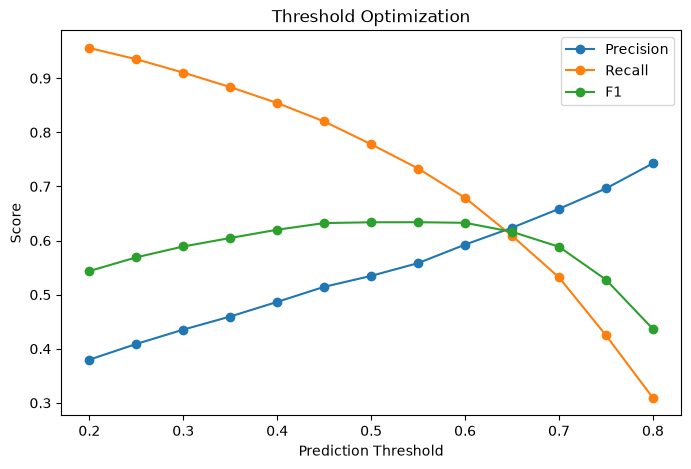

In [112]:
# Plot Precision, Recall and F1
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel(
    "Prediction Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Threshold Optimization"
)

plt.legend()

plt.show()

In [113]:
# Simple threshold selection
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

In [114]:
best_threshold_row

Threshold    0.550000
Precision    0.558329
Recall       0.733110
F1           0.633892
Name: 7, dtype: float64

In [115]:
best_threshold = best_threshold_row[
    "Threshold"
]

print(
    "Selected threshold:",
    best_threshold
)

Selected threshold: 0.5499999999999999


In [116]:
# Train tuned model on all training data
tuned_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [117]:
# Use test set
# Probabilities 
test_prob = tuned_model.predict_proba(
    X_test
)[:, 1]

In [118]:
test_pred = (
    test_prob >= best_threshold
).astype(int)

In [120]:
# Final metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [121]:
# Calculate :
final_accuracy = accuracy_score(
    y_test,
    test_pred
)

final_precision = precision_score(
    y_test,
    test_pred
)

final_recall = recall_score(
    y_test,
    test_pred
)

final_f1 = f1_score(
    y_test,
    test_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

final_pr_auc = average_precision_score(
    y_test,
    test_prob
)

In [122]:
print("FINAL MODEL RESULTS")
print("-------------------")

print(
    "Accuracy :",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall   :",
    round(final_recall, 4)
)

print(
    "F1 Score :",
    round(final_f1, 4)
)

print(
    "ROC-AUC  :",
    round(final_roc_auc, 4)
)

print(
    "PR-AUC   :",
    round(final_pr_auc, 4)
)

print(
    "Threshold:",
    round(best_threshold, 2)
)

FINAL MODEL RESULTS
-------------------
Accuracy : 0.7693
Precision: 0.5495
Recall   : 0.7273
F1 Score : 0.626
ROC-AUC  : 0.842
PR-AUC   : 0.6576
Threshold: 0.55


In [123]:
# Final confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_pred
)

cm

array([[812, 223],
       [102, 272]])

In [124]:
tn, fp, fn, tp = cm.ravel()

print(
    "True Negatives :",
    tn
)

print(
    "False Positives:",
    fp
)

print(
    "False Negatives:",
    fn
)

print(
    "True Positives :",
    tp
)

True Negatives : 812
False Positives: 223
False Negatives: 102
True Positives : 272


In [125]:
# Create final customer risk table
risk_results = X_test.copy()

In [126]:
# Add :
risk_results[
    "actual_churn"
] = y_test.values

In [127]:
risk_results[
    "churn_probability"
] = test_prob

In [128]:
risk_results[
    "predicted_churn"
] = test_pred

In [130]:
# Create risk category:
def assign_risk(probability):

    if probability >= 0.80:
        return "Critical"

    elif probability >= 0.60:
        return "High"

    elif probability >= 0.40:
        return "Medium"

    else:
        return "Low"

In [131]:
risk_results[
    "risk_category"
] = risk_results[
    "churn_probability"
].apply(assign_risk)

In [132]:
risk_results[
    [
        "tenure",
        "contract",
        "monthlycharges",
        "techsupport",
        "churn_probability",
        "risk_category",
        "actual_churn"
    ]
].sort_values(
    "churn_probability",
    ascending=False
).head(20)


,tenure,contract,monthlycharges,techsupport,churn_probability,risk_category,actual_churn
6866,1,Month-to-month,95.45,No,0.950911,Critical,1
4585,1,Month-to-month,85.05,No,0.943179,Critical,1
3380,1,Month-to-month,95.10,No,0.942891,Critical,1
3727,3,Month-to-month,96.60,No,0.938135,Critical,1
6623,1,Month-to-month,76.45,No,0.935948,Critical,1
2464,1,Month-to-month,77.15,No,0.928292,Critical,1
3346,2,Month-to-month,84.05,No,0.927198,Critical,0
1731,1,Month-to-month,69.60,No,0.926802,Critical,1
2729,2,Month-to-month,85.70,No,0.925635,Critical,1
6633,1,Month-to-month,74.50,No,0.924862,Critical,1


In [133]:
# Saving the final ML model
import joblib

In [134]:
joblib.dump(
    tuned_model,
    "../models/churn_model.joblib"
)

['../models/churn_model.joblib']

In [135]:
joblib.dump(
    best_threshold,
    "../models/churn_threshold.joblib"
)

['../models/churn_threshold.joblib']

In [136]:
# Testing that the saved model works
loaded_model = joblib.load(
    "../models/churn_model.joblib"
)

loaded_threshold = joblib.load(
    "../models/churn_threshold.joblib"
)

In [138]:
# select one customer:
customer = X_test.iloc[[0]]

In [139]:
# Predict probability:
probability = loaded_model.predict_proba(
    customer
)[0, 1]

In [140]:
# Prediction:
prediction = int(
    probability >= loaded_threshold
)

In [141]:
# Print
print(
    "Churn Probability:",
    round(probability * 100, 2),
    "%"
)

print(
    "Prediction:",
    "Churn"
    if prediction == 1
    else "Stay"
)

Churn Probability: 3.87 %
Prediction: Stay
